In [19]:
import numpy as np
import pandas as pd 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize 
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from adjustText import adjust_text

In [2]:
df = pd.read_parquet('../data/processed/dblp_eda.parquet')
print(df.shape)
print(df.info())


(3858969, 8)
<class 'pandas.DataFrame'>
Index: 3858969 entries, 0 to 3912876
Data columns (total 8 columns):
 #   Column        Dtype
---  ------        -----
 0   type          str  
 1   year          int64
 2   title         str  
 3   authors       str  
 4   source        str  
 5   author_count  int64
 6   title_length  int64
 7   first_author  str  
dtypes: int64(3), str(5)
memory usage: 939.5 MB
None


In [3]:
df_sample = (
    df[df['year'] < 2026]
    .sample(n=min(200_000, len(df[df['year'] < 2026])), random_state=42)
    .reset_index(drop=True)
)
print(df_sample['year'].value_counts())

year
2024    30516
2025    29224
2023    27457
2022    25119
2021    23978
2020    22630
2019    21748
2018    19328
Name: count, dtype: int64


In [4]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   type          200000 non-null  str  
 1   year          200000 non-null  int64
 2   title         200000 non-null  str  
 3   authors       200000 non-null  str  
 4   source        200000 non-null  str  
 5   author_count  200000 non-null  int64
 6   title_length  200000 non-null  int64
 7   first_author  200000 non-null  str  
dtypes: int64(3), str(5)
memory usage: 47.2 MB


In [5]:
tfidf = TfidfVectorizer(
    max_features=15_000,
    ngram_range=(1, 2),
    min_df=5, 
    max_df=0.85,
    stop_words='english',
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(df_sample['title'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f"Sparse density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix shape: (200000, 15000)
Sparse density: 0.0658%


In [6]:
svd = TruncatedSVD(n_components=100, random_state=42)
X = svd.fit_transform(tfidf_matrix)
explained = svd.explained_variance_ratio_.cumsum()
print(f'Shape after SVD: {X.shape}')
print(f'Explained variance (100 components): {explained[-1]:.2%}')

Shape after SVD: (200000, 100)
Explained variance (100 components): 11.83%


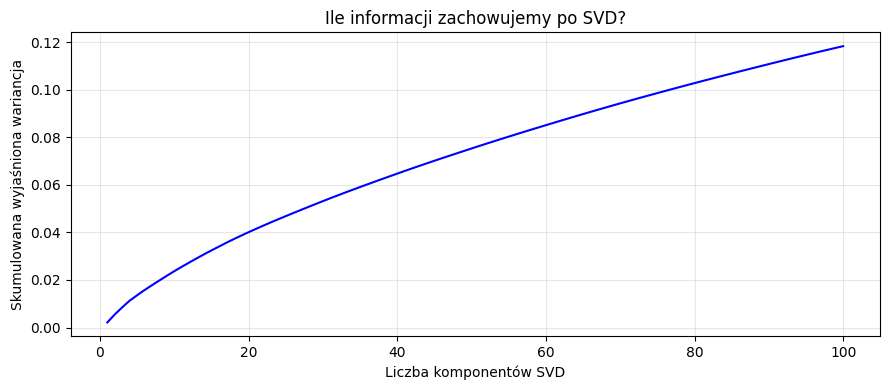

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, 101), explained, 'b-')
plt.xlabel("Liczba komponentów SVD")
plt.ylabel("Skumulowana wyjaśniona wariancja")
plt.title("Ile informacji zachowujemy po SVD?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
X_normalized = normalize(X, norm='l2')
print(f"Shape: {X_normalized.shape}")
print(f"Przykładowa norma wektora: {np.linalg.norm(X_normalized[0]):.4f}") 

Shape: (200000, 100)
Przykładowa norma wektora: 1.0000


k= 5 | inertia=178,796
k=10 | inertia=168,560
k=15 | inertia=159,760
k=20 | inertia=150,556
k=25 | inertia=144,353
k=30 | inertia=141,072


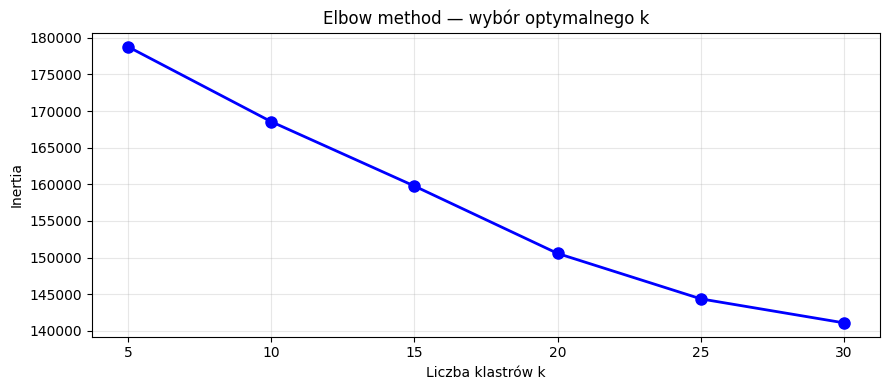

In [9]:
inertias = []
K_range = range(5, 35, 5)

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=10_000)
    km.fit(X_normalized)
    inertias.append(km.inertia_)
    print(f"k={k:2d} | inertia={km.inertia_:,.0f}")

plt.figure(figsize=(9, 4))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Liczba klastrów k")
plt.ylabel("Inertia")
plt.title("Elbow method — wybór optymalnego k")
plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
BEST_K = 20

km_final = MiniBatchKMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=5,           
    batch_size=10_000
)

df_sample['cluster'] = km_final.fit_predict(X_normalized)

print(f"Rozkład klastrów:")
print(df_sample['cluster'].value_counts().sort_index())

Rozkład klastrów:
cluster
0     12892
1     12769
2     20637
3      4082
4      7930
5      8239
6      8480
7      6489
8      7386
9      7611
10     4918
11     7189
12    37260
13     8894
14     5656
15    17131
16     5233
17     4877
18     7438
19     4889
Name: count, dtype: int64


In [11]:
feature_names = tfidf.get_feature_names_out()
cluster_labels = {}

for c in range(BEST_K):
    idx = df_sample[df_sample['cluster'] == c].index
    cluster_tfidf = tfidf_matrix[idx].mean(axis=0).A1
    top_words = [feature_names[i] for i in cluster_tfidf.argsort()[::-1][:7]]
    cluster_labels[c] = ' | '.join(top_words)
    print(f"Klaster {c:2d} ({len(idx):>6,} rek.): {cluster_labels[c]}")

df_sample['cluster_label'] = df_sample['cluster'].map(cluster_labels)

Klaster  0 (12,892 rek.): based | model | algorithm | approach | optimization | image | algorithm based
Klaster  1 (12,769 rek.): learning | multi | reinforcement | reinforcement learning | federated | federated learning | agent
Klaster  2 (20,637 rek.): human | performance | estimation | virtual | high | reality | robot
Klaster  3 ( 4,082 rek.): machine | machine learning | learning | using machine | using | based | machine translation
Klaster  4 ( 7,930 rek.): network | neural network | neural | based | convolutional | convolutional neural | network based
Klaster  5 ( 8,239 rek.): networks | neural networks | neural | convolutional | wireless | convolutional neural | graph
Klaster  6 ( 8,480 rek.): using | based | model | estimation | classification | recognition | prediction
Klaster  7 ( 6,489 rek.): method | segmentation | semantic | image | based | images | semantic segmentation
Klaster  8 ( 7,386 rek.): control | model | predictive | based | predictive control | model predictive 

In [12]:
human_labels = {
    0: "Optimization & Algorithms",
    1: "Federated & RL",
    2: "Robotics & XR",
    3: "Machine Learning & NLP",
    4: "CNN & Neural Nets",
    5: "Graph & Wireless Networks",
    6: "Classification & Prediction",
    7: "Computer Vision",
    8: "Control Systems",
    9: "Detection & Anomaly",
    10: "Empirical Studies",
    11: "Cyber-Physical Systems",
    12: "AI & Knowledge Systems",
    13: "Big Data",
    14: "Deep Learning",
    15: "Algorithms & Graph Theory",
    16: "LLMs & Foundation Models",
    17: "Systems Design",
    18: "Sentiment & Analytics",
    19: "Digital Twin & Industry 4.0"
}

df_sample['cluster_name'] = df_sample['cluster'].map(human_labels)
print(df_sample[['title', 'year', 'cluster', 'cluster_name']].head(10))

                                               title  year  cluster  \
0  An evidence theory based model fusion method f...  2020       18   
1  A free parameter dependent family of polynomia...  2025       15   
2  Simulations of Common Unsupervised Domain Adap...  2025       12   
3  Behavioural supply chain management: evolving ...  2024       18   
4  Zero-Shot Video Event Detection With High-Orde...  2022        9   
5  Usability Problem Evaluation Method for E-Shop...  2022        7   
6    Understanding Emotional Hijacking in Metaverse.  2024       12   
7  How Do Papers Make Into Machine Learning Frame...  2025        3   
8    Improved Path-length Regret Bounds for Bandits.  2019       15   
9  Polarity Is All You Need to Learn and Transfer...  2023       12   

                cluster_name  
0      Sentiment & Analytics  
1  Algorithms & Graph Theory  
2     AI & Knowledge Systems  
3      Sentiment & Analytics  
4        Detection & Anomaly  
5            Computer Vision  
6

/home/szymon/dblp_project/venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


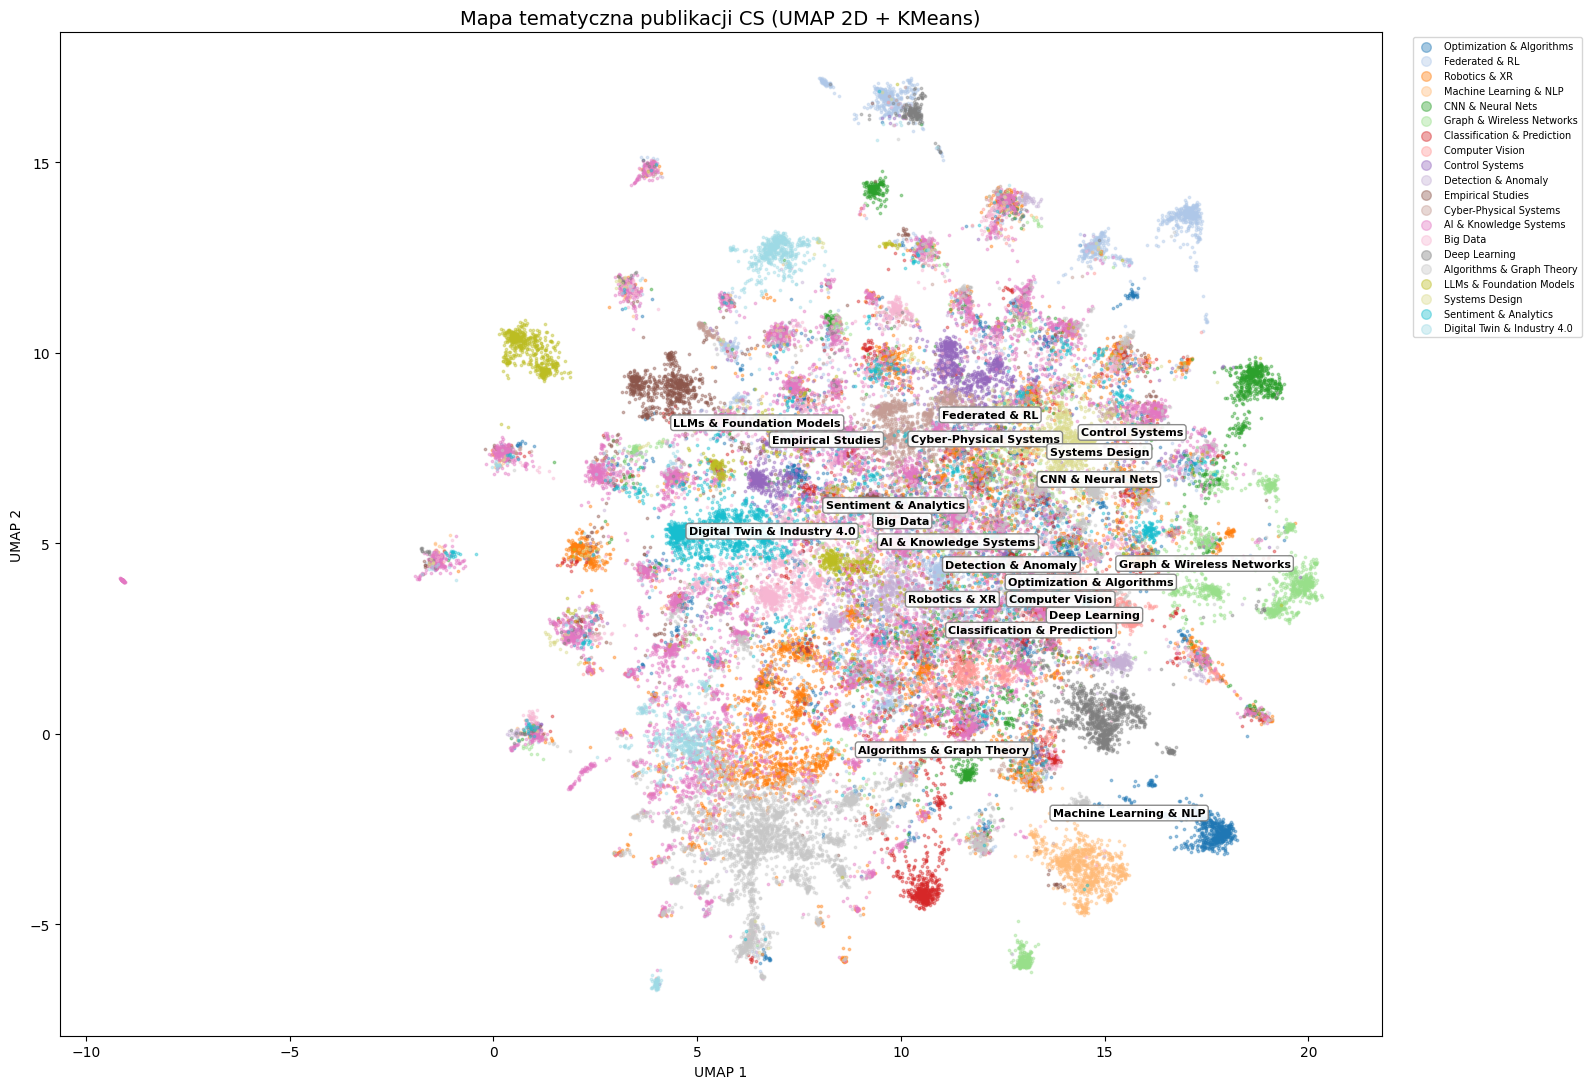

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.5, metric='cosine')
X_umap = reducer.fit_transform(X_normalized[:50_000])  

fig, ax = plt.subplots(figsize=(16, 11), facecolor='white')
ax.set_facecolor('white')

colors = plt.cm.tab20(np.linspace(0, 1, BEST_K))
texts = []

for cluster_id in range(BEST_K):
    mask = df_sample['cluster'][:50_000] == cluster_id
    if mask.sum() == 0:
        continue
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=[colors[cluster_id]], alpha=0.4, s=3,
               label=human_labels[cluster_id])
    cx = X_umap[mask, 0].mean()
    cy = X_umap[mask, 1].mean()
    texts.append(ax.text(cx, cy, human_labels[cluster_id],
                         fontsize=8, fontweight='bold',
                         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9)))

adjust_text(texts, ax=ax)  

ax.set_title("Mapa tematyczna publikacji CS (UMAP 2D + KMeans)", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, markerscale=4)
plt.tight_layout()
plt.show()

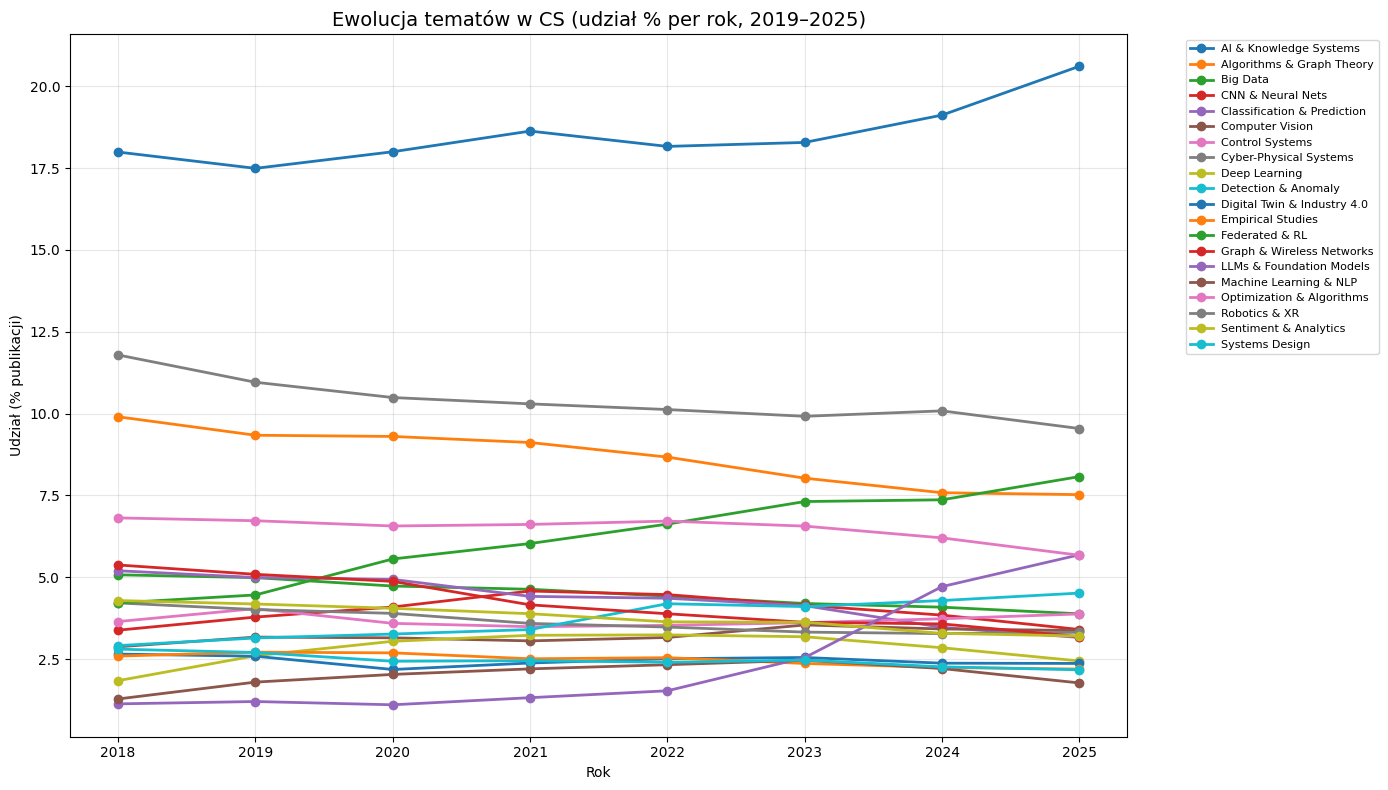

In [ ]:
cluster_year = (
    df_sample.groupby(['year', 'cluster_name'])
    .size()
    .unstack(fill_value=0)
)

cluster_year_pct = cluster_year.div(cluster_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
for col in cluster_year_pct.columns:
    ax.plot(cluster_year_pct.index, cluster_year_pct[col], marker='o', linewidth=2, label=col)

ax.set_title("Ewolucja tematów w CS (udział % per rok, 2019–2025)", fontsize=14)
ax.set_xlabel("Rok")
ax.set_ylabel("Udział (% publikacji)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
df_sample.to_parquet("../data/processed/dblp_clustered.parquet", index=False)

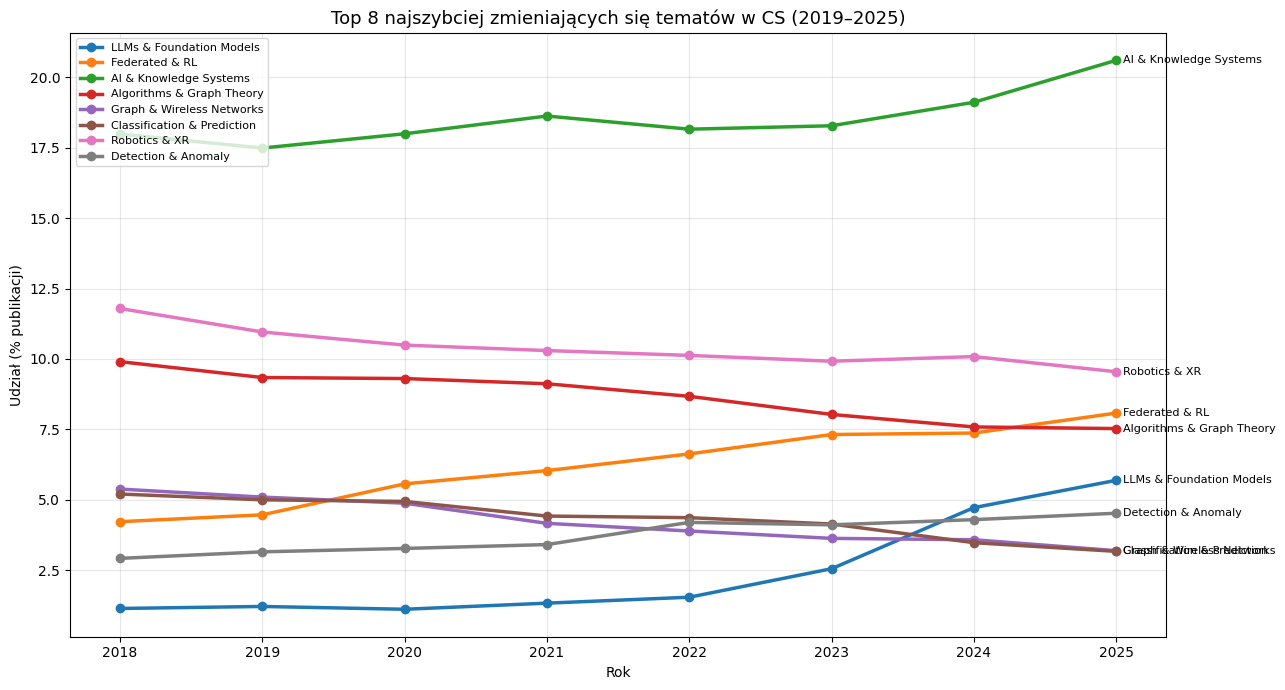

In [ ]:
top_volatile = cluster_year_pct.var().nlargest(8).index

fig, ax = plt.subplots(figsize=(13, 7))
for col in top_volatile:
    ax.plot(cluster_year_pct.index, cluster_year_pct[col], 
            marker='o', linewidth=2.5, label=col)
    ax.annotate(col, 
                xy=(cluster_year_pct.index[-1], cluster_year_pct[col].iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, va='center')

ax.set_title("Top 8 najszybciej zmieniających się tematów w CS (2019–2025)", fontsize=13)
ax.set_xlabel("Rok")
ax.set_ylabel("Udział (% publikacji)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

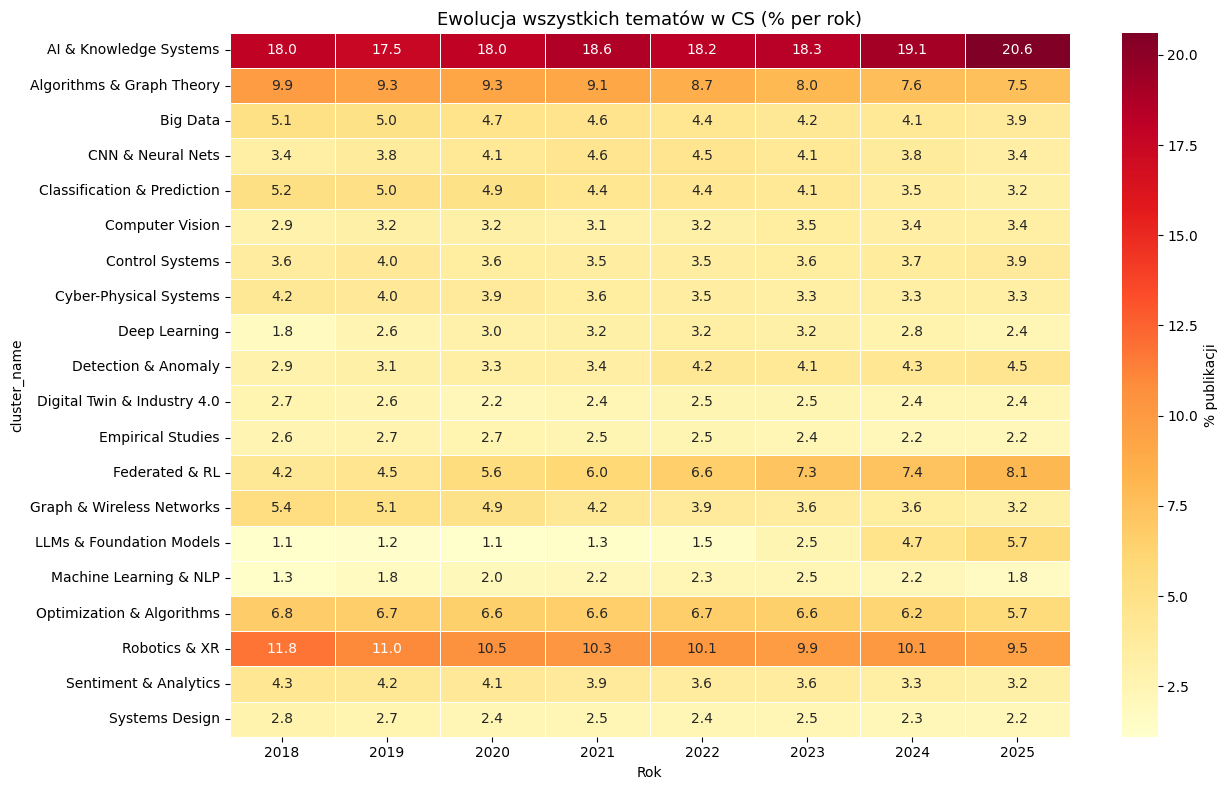

In [ ]:
plt.figure(figsize=(13, 8))
sns.heatmap(cluster_year_pct.T, 
            cmap='YlOrRd', 
            annot=True, fmt='.1f',
            linewidths=0.5,
            cbar_kws={'label': '% publikacji'})
plt.title("Ewolucja wszystkich tematów w CS (% per rok)", fontsize=13)
plt.xlabel("Rok")
plt.tight_layout()
plt.show()